Suspicious Fake News Analyzer(SUFNA)

Data source : Kaggle

Tools and Libraries : Jupyter notebook, Pandas, numpy, sklearn(Logistic Model, Vectorizer(TfidfVectorizer),metrics)

Execution

A machine learning system  was built to detect the likelihood of a news being fake using Natural Language Processing(NLP).

First, each news article was converted into numerical features using TF-IDF, which measures how important each word is in a document relative to the dataset.
TF-IDF measures how important a word is in a document relative to the whole dataset.
Words that appear frequently in one article but not across many articles get higher weights, allowing the model to focus on meaningful signals instead of common words.

The vocabulary was limited to the most informative 5000 words to reduce noise and improve efficiency.

Then Logistic Regression classifier was trained on the dataset to learn how strongly each word indicates fake or real news.

For example, words like “said” strongly indicate real news, while sensational words like “video” or “just” tend to indicate fake news.

By combining these weighted signals, the model predicts whether an article is fake or real.

The model achieved around 97.71% accuracy, showing that linguistic patterns can effectively distinguish reliable reporting from misinformation.

Summary
* TF-IDF converts articles into numerical features
* Logistic Regression learns which words indicate fake or real news
* Each word contributes a weighted vote toward the final prediction



In [22]:
import pandas as pd
df =pd.read_csv('Fake.csv')
df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [23]:
df.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [24]:
df1 = pd.read_csv('True.csv')
df1.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


assigning values to outcomes 

In [25]:
df['label']=1
df1['label']=0

joining the fake and true datasets

In [26]:
df =pd.concat([df, df1], axis =0)

reshuffling the datasets

In [27]:
df=df.sample(frac =1, random_state =1).reset_index(drop =True)
df.head(10)

,title,text,subject,date,label
0,Trump Calls For This Racist Policy To Be Forc...,Donald Trump is calling for one of the most co...,News,"September 21, 2016",1
1,Republican ex-defense secretary Cohen backs Hi...,WASHINGTON (Reuters) - Former Republican U.S. ...,politicsNews,"September 7, 2016",0
2,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ...",You re never to young to commit jihad Teachers...,politics,"May 9, 2017",1
3,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...,Laura Ingraham reminds the Never Trump people ...,politics,"Jul 21, 2016",1
4,Germany's Merkel suffers state vote setback as...,BERLIN/HANOVER (Reuters) - Germany s Social De...,worldnews,"October 14, 2017",0
5,WHOA! MELANIA TRUMP BREAKS HER SILENCE…Fires B...,Melanie Trump is more than just a pretty face....,politics,"Oct 17, 2016",1
6,Study Shows Democrats Are Better Drivers For ...,You don t have to look beyond Washington to pr...,News,"February 1, 2017",1
7,U.S. lawmakers want moratorium on commercial f...,WASHINGTON (Reuters) - Two leading critics of ...,politicsNews,"September 7, 2016",0
8,The new risk for Europe: an inward-looking Ger...,"BERLIN (Reuters) - In 2008, in a fit of pique ...",worldnews,"September 26, 2017",0
9,"Trump still standing, but damaged by Comey's t...",WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"June 9, 2017",0


In [28]:
print(f'Shape of fake news data : {df.shape}')

Shape of fake news data : (44898, 5)


In [29]:
df.isna().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

since most of the true dataset have in it reuters, we removed it to prevent the model to base its prediction on that.

In [30]:
# import re

# def remove_reuters(text):
#     text = re.sub(r'^[A-Z/\s]+\(Reuters\)\s-', '', text)
#     return text

df["text"] = df["text"].str.replace(r'^[A-Z/\s]+\s*\(Reuters\)\s*-\s*', '', regex=True)
df['text'] = df['text'].str.replace('Reuters', '', regex=False)



creating content column from title and text

In [31]:
df['content']=df['title'] +' '+ df['text']

In [32]:
df.duplicated().sum()

np.int64(209)

droping duplicates

In [33]:
df =df.drop_duplicates(subset=['content'])
df.duplicated().sum()

np.int64(0)

In [34]:
df.head(10)

,title,text,subject,date,label,content
0,Trump Calls For This Racist Policy To Be Forc...,Donald Trump is calling for one of the most co...,News,"September 21, 2016",1,Trump Calls For This Racist Policy To Be Forc...
1,Republican ex-defense secretary Cohen backs Hi...,Former Republican U.S. Defense Secretary Willi...,politicsNews,"September 7, 2016",0,Republican ex-defense secretary Cohen backs Hi...
2,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ...",You re never to young to commit jihad Teachers...,politics,"May 9, 2017",1,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ..."
3,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...,Laura Ingraham reminds the Never Trump people ...,politics,"Jul 21, 2016",1,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...
4,Germany's Merkel suffers state vote setback as...,Germany s Social Democrats (SPD) defeated Ange...,worldnews,"October 14, 2017",0,Germany's Merkel suffers state vote setback as...
5,WHOA! MELANIA TRUMP BREAKS HER SILENCE…Fires B...,Melanie Trump is more than just a pretty face....,politics,"Oct 17, 2016",1,WHOA! MELANIA TRUMP BREAKS HER SILENCE…Fires B...
6,Study Shows Democrats Are Better Drivers For ...,You don t have to look beyond Washington to pr...,News,"February 1, 2017",1,Study Shows Democrats Are Better Drivers For ...
7,U.S. lawmakers want moratorium on commercial f...,Two leading critics of President Barack Obama’...,politicsNews,"September 7, 2016",0,U.S. lawmakers want moratorium on commercial f...
8,The new risk for Europe: an inward-looking Ger...,"In 2008, in a fit of pique over Angela Merkel ...",worldnews,"September 26, 2017",0,The new risk for Europe: an inward-looking Ger...
9,"Trump still standing, but damaged by Comey's t...",President Donald Trump survived one of the big...,politicsNews,"June 9, 2017",0,"Trump still standing, but damaged by Comey's t..."


splitting the dataset

In [35]:
from sklearn.model_selection import train_test_split
X = df['content']
y =df['label']
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size =0.3, random_state =1, stratify =y)

converting word to wighted values base on the importance and how rarely thet are

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer =TfidfVectorizer( stop_words ='english', max_features =5000)
X_train_vec =vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

applying Logistic Regression Model

In [37]:
from sklearn.linear_model import LogisticRegression
model =LogisticRegression()
model.fit(X_train_vec, y_train)
y_pred =model.predict(X_test_vec)

getting the metrics scores

In [38]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
accuracy = accuracy_score(y_test, y_pred)
precision =precision_score(y_test, y_pred)
f1 =f1_score(y_test, y_pred)
recall= recall_score(y_test, y_pred)

In [39]:
print(f'Accuracy = {accuracy}')
print(f'Precision = {precision}')
print(f'Recall =  {recall}')
print(f'F1 = {f1}')

Accuracy = 0.9771564950562563
Precision = 0.9831535112625402
Recall =  0.9666852782430672
F1 = 0.9748498498498499


generally the accuracy level of model prediction is high.
most of the times when it prdicts fake, its 98.31% right and 96.66% of the fake news was captured. On average, the the perfomance level of the model is 97.48%

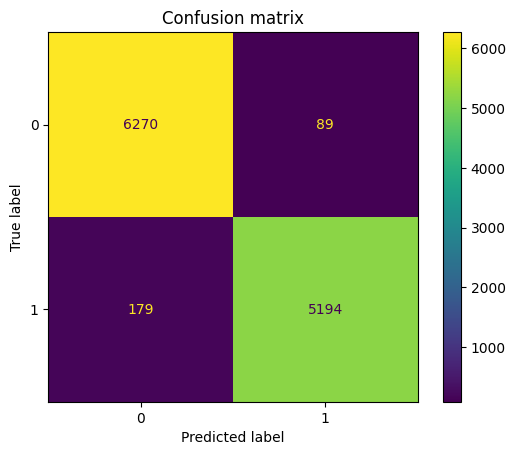

In [40]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion matrix')
plt.show()


from the confusion matrix, 6270 real news was predicted right and 89 wrong
5194 fake news was predicted right with wrong prediction 179

authenticating whether the values are due to class biased or data leakage

In [41]:
#value counts 
df['label'].value_counts(normalize =True)

label
0    0.542053
1    0.457947
Name: proportion, dtype: float64

authenticating metric values

In [42]:
from sklearn.dummy import DummyClassifier
dummy =DummyClassifier(strategy = 'most_frequent')
dummy.fit(X_train_vec, y_train)
ypred =dummy.predict(X_test_vec)

In [43]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score
accuracy = accuracy_score(y_test, ypred)
precision =precision_score(y_test, ypred)
f1 =f1_score(y_test, ypred)
recall= recall_score(y_test, ypred)
print(f'Accuracy = {accuracy}')
print(f'Precision = {precision}')
print(f'Recall =  {recall}')
print(f'F1 = {f1}')

Accuracy = 0.5420218206614388
Precision = 0.0
Recall =  0.0
F1 = 0.0


C:\Users\njedr\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
df['content'].head(10)

0     Trump Calls For This Racist Policy To Be Forc...
1    Republican ex-defense secretary Cohen backs Hi...
2    TEACHER QUITS JOB After 5th, 6th Grade Muslim ...
3    LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...
4    Germany's Merkel suffers state vote setback as...
5    WHOA! MELANIA TRUMP BREAKS HER SILENCE…Fires B...
6     Study Shows Democrats Are Better Drivers For ...
7    U.S. lawmakers want moratorium on commercial f...
8    The new risk for Europe: an inward-looking Ger...
9    Trump still standing, but damaged by Comey's t...
Name: content, dtype: object

comparing prediction with actuals

In [45]:
(y_pred == y_test).mean()

np.float64(0.9771564950562563)

checking whether there is mixed up between training data and test data

In [46]:
set(X_train).intersection(set(X_test))

set()

checking which words the prediction was mostly based on 

In [47]:
import numpy as np
model.coef_.shape
#np.argsort
model.coef_[0]

array([ 0.72645155,  0.00721313,  0.07474906, ..., -0.02469474,
       -0.59389005, -1.07398425])

In [48]:
import numpy as np

# Get the feature names from TF-IDF
feature_names = vectorizer.get_feature_names_out()

# Get the coefficients from the Logistic Regression model
coefficients = model.coef_[0]  # shape = (n_features,)

# Top 20 words indicating the "fake" class (positive coefficients)
top_fake_idx = np.argsort(coefficients)[-20:]
top_fake_words = feature_names[top_fake_idx]
top_fake_values = coefficients[top_fake_idx]

# Top 20 words indicating the "real" class (negative coefficients)
top_real_idx = np.argsort(coefficients)[:20]
top_real_words = feature_names[top_real_idx]
top_real_values = coefficients[top_real_idx]

# Print results
print("Top words indicating FAKE news:")
for word, val in zip(top_fake_words[::-1], top_fake_values[::-1]):
    print(f"{word}: {val:.3f}")

print("\nTop words indicating REAL news:")
for word, val in zip(top_real_words, top_real_values):
    print(f"{word}: {val:.3f}")

Top words indicating FAKE news:
video: 9.775
just: 7.241
image: 6.878
featured: 6.555
gop: 6.455
read: 6.191
hillary: 5.249
getty: 5.164
watch: 5.030
mr: 4.864
com: 4.832
america: 4.603
images: 4.319
like: 3.981
pic: 3.892
breaking: 3.890
sen: 3.889
rep: 3.860
isis: 3.686
obama: 3.491

Top words indicating REAL news:
said: -17.161
wednesday: -5.758
tuesday: -5.357
thursday: -5.265
republican: -5.061
friday: -4.869
monday: -4.281
presidential: -4.181
nov: -4.007
reporters: -3.402
minister: -3.399
told: -3.228
democratic: -3.194
comment: -3.097
spokesman: -2.978
edt: -2.942
representatives: -2.888
senate: -2.821
britain: -2.638
house: -2.471
